In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson
import scipy

In [48]:
file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 2-15 PM Thu, Oct 31, 2024 Run8 .csv"

data = pd.read_csv(file, index_col="Time")
time = data.index

acceleration0 = data['0'] #Using only accelerometer 0

def clamp(value, lower=0.015, upper=0.1):
    return max(lower, min(value, upper))

def get_peaks(acceleration0):
    """
    acceleration0: accelerometer data, measured to the 10,000th of a second
    Returns: x and y coordinates of peaks
    """
    percentile = np.percentile(acceleration0, 99.5)
    percent_of_max = 0.1*np.max(acceleration0)

    height = clamp(max(percentile, percent_of_max))
    distance = 350 + 5 / height

    x, y = scipy.signal.find_peaks(acceleration0, distance=distance, height=height)
    x = x / 10000
    y = y["peak_heights"]  # unpack data
    return x, y

def get_best_gmm_by_bic_jump(peak_amplitudes, n_components_range=range(1, 4), threshold=-50):
    """
    Fits Gaussian Mixture Models (GMM) for different numbers of components and selects the best model 
    based on the largest negative jump in BIC (Bayesian Information Criterion), provided the jump is ≤ threshold.
    
    Parameters:
        peak_amplitudes (numpy array): The data to fit the GMM on.
        n_components_range (range): The range of components to evaluate.
        threshold (float): The minimum BIC decrease required to consider the jump optimal.
    
    Returns:
        best_gmm (GaussianMixture): The best-fitting GMM model.
        best_n_components (int): The optimal number of components.
        bic_list (list): List of computed BIC values.
    """
    best_gmm = None
    best_n_components = 1
    bic_list = []
    gmm_list = []

    # Fit models and store BIC values
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(peak_amplitudes)
        bic = gmm.bic(peak_amplitudes)
        bic_list.append(round(float(bic), 2))
        gmm_list.append(gmm)

    # Compute BIC differences
    bic_diffs = np.diff(bic_list)

    # Determine the best model based on the largest negative jump in BIC (≤ threshold)
    if len(bic_diffs) > 0:
        greatest_decrease_index = np.argmin(bic_diffs)  # Find the largest negative jump
        if bic_diffs[greatest_decrease_index] <= threshold:
            best_n_components = greatest_decrease_index + 2  # Adjust index to component count
            best_gmm = gmm_list[greatest_decrease_index + 1]
        else:
            best_gmm = gmm_list[0]  # Default to 1 component if no significant decrease found

    return best_gmm, best_n_components, bic_list


BIC values: [-234.41, -415.13, -409.57]
Best number of components: 2


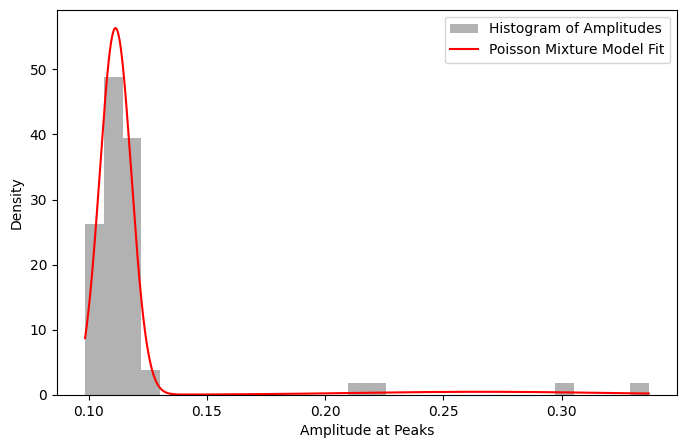

In [49]:
# Extract peak amplitudes
peaks, _ = get_peaks(acceleration0)
peak_amplitudes = acceleration0.loc[peaks].values.reshape(-1, 1)

# Get the best model based on BIC jump
best_gmm, best_n_components, bic_list = get_best_gmm_by_bic_jump(peak_amplitudes)

# Print results
print(f"BIC values: {bic_list}")
print(f"Best number of components: {best_n_components}")

# Visualizing the mixture model
x = np.linspace(min(peak_amplitudes), max(peak_amplitudes), 1000).reshape(-1, 1)
log_prob = best_gmm.score_samples(x)
responsibilities = np.exp(log_prob)

plt.figure(figsize=(8, 5))
plt.hist(peak_amplitudes, bins=30, density=True, alpha=0.6, color='gray', label="Histogram of Amplitudes")
plt.plot(x, responsibilities, label="Poisson Mixture Model Fit", color='red')
plt.xlabel("Amplitude at Peaks")
plt.ylabel("Density")
plt.legend()
plt.show()


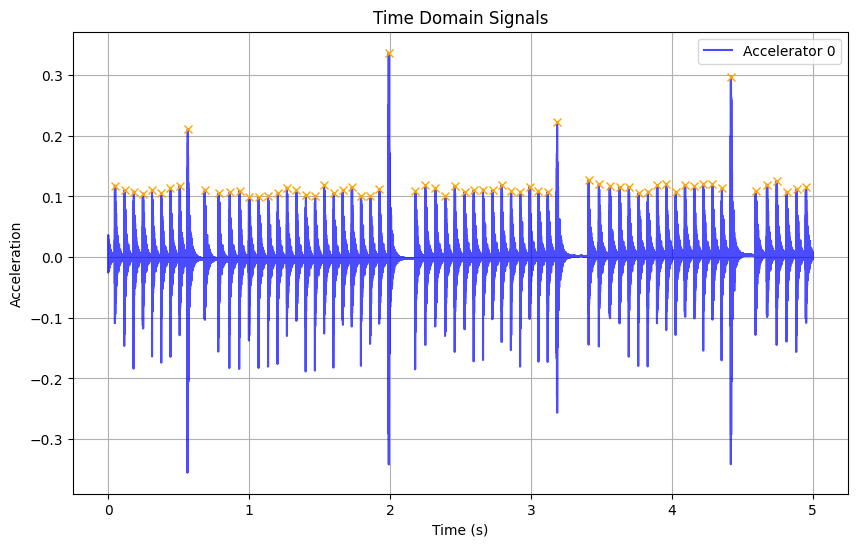

In [50]:
# 2. Plot the time domain signals
plt.figure(figsize=(10, 6))
plt.plot(time, acceleration0, label='Accelerator 0', color='blue', alpha=0.7)
plt.plot(peaks, acceleration0.loc[peaks], "x", color="orange")
plt.title('Time Domain Signals')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration')
plt.legend()
plt.grid(True)
plt.show()

In [51]:
# Get the probabilities of each amplitude belonging to each component
probabilities = best_gmm.predict_proba(peak_amplitudes)

# Assign each amplitude to the component with the highest probability
assigned_components = np.argmax(probabilities, axis=1)

# Create a DataFrame for better visualization
amplitude_components = pd.DataFrame({
    "Amplitude": peak_amplitudes.flatten(),
    "Component": assigned_components
})

# Display the grouped amplitudes
for component in range(best_gmm.n_components):
    print(f"Component {component}:")
    print(amplitude_components[amplitude_components["Component"] == component]["Amplitude"].values)
    print("\n")


Component 0:
[0.11786012 0.11041567 0.10802993 0.10472278 0.11074272 0.1050659
 0.11310726 0.11773675 0.11088279 0.10488534 0.10658229 0.10932014
 0.09909993 0.09845804 0.1012338  0.1060297  0.11455747 0.11058851
 0.10211793 0.10077182 0.11828548 0.10555037 0.11065919 0.11500725
 0.10020253 0.10070242 0.11204386 0.10807555 0.11870698 0.11390915
 0.10097743 0.11673375 0.10750369 0.11015608 0.11130237 0.1101246
 0.11864208 0.10866668 0.1077395  0.11628461 0.10925846 0.10773179
 0.12677276 0.12056713 0.11647673 0.11550843 0.11569926 0.10523746
 0.10806462 0.11845189 0.12080744 0.10684509 0.11858169 0.11694064
 0.1205652  0.12050994 0.1139869  0.10857159 0.1194157  0.12531613
 0.10775685 0.11185688 0.11508499]


Component 1:
[0.21059956 0.3368236  0.22242226 0.29740903]


